#  Simulation A/B Tests 
On n'a pas accès à une vraie marketplace pour faire un vrai test. Mais on peut simuler ce qui se passerait en ajoutant du bruit aléatoire aux résultats,comme dans la vraie vie où les ventes varient naturellement.

## Objectif
Valider les recommandations de prix via des simulations A/B. Avant d'appliquer les nouveaux prix en production, on simule ce qui se passerait pour s'assurer que le gain est réel.

## Principe
- **Groupe A** : 50% des clients → prix actuel
- **Groupe B** : 50% des clients → prix optimal
- On répète la simulation 10 000 fois pour avoir des résultats fiables

## Questions auxquelles on répond
1. Le gain est-il statistiquement significatif ?
2. Quelle est la probabilité que le nouveau prix soit meilleur ?
3. Quel est le gain minimum garanti avec 95% de confiance ?

## 1. Chargement des données

In [ ]:
# ============================================================
# IMPORTS ET CHARGEMENT DES DONNÉES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# On Fixe le seed pour avoir des résultats reproductibles
# (le même seed donnera toujours les mêmes nombres aléatoires)
np.random.seed(42)

# Chargement des résultats d'optimisation
optim_df = pd.read_csv('../data/optimisation_prix.csv')

# On garde uniquement les catégories avec un gain > 0
optim_df = optim_df[optim_df['gain_rs'] > 0].reset_index(drop=True)

print(" Données chargées")
print(f"   - Catégories à tester : {len(optim_df)}")
print(f"\n=== Aperçu ===")
print(optim_df[['categorie', 'prix_actuel', 'prix_optimal', 'gain_rs', 'gain_pct']].head())

✅ Données chargées
   - Catégories à tester : 48

=== Aperçu ===
                 categorie  prix_actuel  prix_optimal    gain_rs  gain_pct
0           Beauté & Santé       130.28        156.34  243333.06     19.73
1        Montres & Cadeaux       199.04        238.85  230154.67     19.74
2  Literie & Salle de bain        93.44        112.13  199790.62     19.52
3          Sport & Loisirs       113.25        135.90  187941.28     19.68
4             Informatique       116.26        139.51  174505.78     19.64


## 2. Fonction de simulation A/B

Pour chaque catégorie, on simule 10 000 fois ce qui se passerait si on testait le nouveau prix sur 50% des clients.

On ajoute du bruit aléatoire pour simuler la variabilité naturelle des ventes (météo, saisonnalité, concurrence...).

In [5]:
# ============================================================
# FONCTION DE SIMULATION A/B
# ============================================================

def simuler_ab_test(ca_actuel, ca_optimal, n_simulations=10000):
    """
    Simule un test A/B pour une catégorie.
    
    Paramètres :
    - ca_actuel     : CA avec le prix actuel
    - ca_optimal    : CA avec le prix optimal estimé
    - n_simulations : nombre de simulations (défaut : 10 000)
    
    Retourne :
    - prob_gain     : probabilité que le prix optimal soit meilleur
    - gain_median   : gain médian simulé
    - gain_min_95   : gain minimum avec 95% de confiance
    """
    
    gains = []
    
    for _ in range(n_simulations):
        # Bruit aléatoire de ±10% pour simuler la variabilité naturelle
        bruit = np.random.normal(0, 0.10)
        
        # Groupe A : prix actuel avec bruit
        ca_groupe_a = ca_actuel * (1 + bruit)
        
        # Groupe B : prix optimal avec bruit
        ca_groupe_b = ca_optimal * (1 + bruit)
        
        gains.append(ca_groupe_b - ca_groupe_a)
    
    gains = np.array(gains)
    
    # Probabilité que le groupe B soit meilleur que A
    prob_gain = (gains > 0).mean() * 100
    
    # Gain médian simulé
    gain_median = np.median(gains)
    
    # Gain minimum avec 95% de confiance (percentile 5)
    gain_min_95 = np.percentile(gains, 5)
    
    return round(prob_gain, 1), round(gain_median, 0), round(gain_min_95, 0)

# Test sur Beauté & Santé
ligne = optim_df[optim_df['categorie'] == 'Beauté & Santé'].iloc[0]
prob, gain_med, gain_min = simuler_ab_test(
    ligne['ca_actuel'], 
    ligne['ca_optimal']
)

print(f"=== Test A/B simulé : Beauté & Santé ===")
print(f"Probabilité que le nouveau prix soit meilleur : {prob}%")
print(f"Gain médian simulé                           : {gain_med:,.0f} R$")
print(f"Gain minimum garanti à 95%                   : {gain_min:,.0f} R$")

=== Test A/B simulé : Beauté & Santé ===
Probabilité que le nouveau prix soit meilleur : 100.0%
Gain médian simulé                           : 243,270 R$
Gain minimum garanti à 95%                   : 203,065 R$


On a 100% de probabilité que le nouveau prix soit meilleur donc le gain est certain. De plus le gain minimum garanti à 95% est 203 065 R$, donc même dans le pire cas, on gagne au moins 203k R$.

## 3. Simulation pour toutes les catégories

On applique la simulation sur les 48 catégories  
et on compile les résultats.

In [6]:
# ============================================================
# SIMULATION A/B POUR TOUTES LES CATÉGORIES
# ============================================================

resultats_ab = []

for _, ligne in optim_df.iterrows():
    
    prob, gain_med, gain_min = simuler_ab_test(
        ligne['ca_actuel'],
        ligne['ca_optimal']
    )
    
    resultats_ab.append({
        'categorie'    : ligne['categorie'],
        'opportunite'  : ligne['opportunite'],
        'prix_actuel'  : ligne['prix_actuel'],
        'prix_optimal' : ligne['prix_optimal'],
        'gain_estime'  : ligne['gain_rs'],
        'gain_median'  : gain_med,
        'gain_min_95'  : gain_min,
        'prob_gain'    : prob
    })

ab_df = pd.DataFrame(resultats_ab)
ab_df = ab_df.sort_values('gain_median', ascending=False).reset_index(drop=True)

# Résumé
print("=" * 60)
print("      RÉSULTATS DES SIMULATIONS A/B")
print("=" * 60)
print(f"""
 Catégories testées          : {len(ab_df)}
 Prob. gain > 95%            : {(ab_df['prob_gain'] >= 95).sum()}
 Prob. gain = 100%           : {(ab_df['prob_gain'] == 100).sum()}

 Gain médian total simulé    : {ab_df['gain_median'].sum():>12,.0f} R$
 Gain minimum garanti (95%)  : {ab_df['gain_min_95'].sum():>12,.0f} R$
""")
print("=" * 60)

print(f"\n=== Top 10 catégories ===")
print(ab_df.head(10)[['categorie', 'gain_estime', 'gain_median', 'gain_min_95', 'prob_gain']].to_string(index=False))

      RÉSULTATS DES SIMULATIONS A/B

 Catégories testées          : 48
 Prob. gain > 95%            : 48
 Prob. gain = 100%           : 48

 Gain médian total simulé    :    2,424,666 R$
 Gain minimum garanti (95%)  :    2,026,576 R$


=== Top 10 catégories ===
              categorie  gain_estime  gain_median  gain_min_95  prob_gain
         Beauté & Santé    243333.06     243719.0     204173.0      100.0
      Montres & Cadeaux    230154.67     230022.0     192939.0      100.0
Literie & Salle de bain    199790.62     199583.0     166814.0      100.0
        Sport & Loisirs    187941.28     188121.0     156858.0      100.0
           Informatique    174505.78     174649.0     145355.0      100.0
   Meubles & Décoration    140373.79     140663.0     117636.0      100.0
    Ustensiles Ménagers    122532.64     122473.0     102378.0      100.0
                Gadgets    117493.78     117406.0      97975.0      100.0
             Automobile    114279.61     114247.0      95491.0      100.

Résultat très intéressant, 48/48 catégories à 100% de probabilité donc le gain est certain pour toutes les catégories. De plus le gain minimum garanti à 95% est 2 026 576 R$, ce qui veut dire que dans le pire des scénario on est sur de gagner plus de 2M R$.

## 4. Visualisation des simulations

On visualise la distribution des gains simulés  
pour les 3 meilleures catégories.

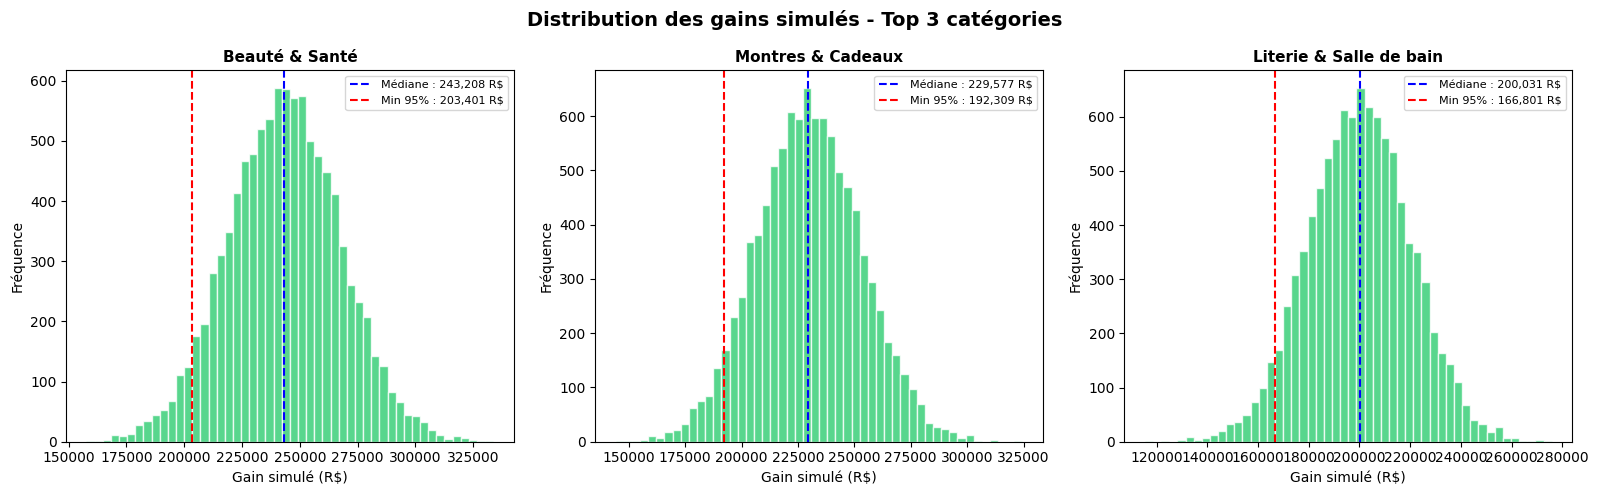

 Graphique sauvegardé dans outputs/


In [7]:
# ============================================================
# VISUALISATION DES DISTRIBUTIONS DE GAINS SIMULÉS
# ============================================================

top3 = ab_df.head(3)['categorie'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, categorie in enumerate(top3):
    ligne = optim_df[optim_df['categorie'] == categorie].iloc[0]
    
    # Simuler 10 000 gains
    gains = []
    for _ in range(10000):
        bruit = np.random.normal(0, 0.10)
        ca_a = ligne['ca_actuel'] * (1 + bruit)
        ca_b = ligne['ca_optimal'] * (1 + bruit)
        gains.append(ca_b - ca_a)
    
    gains = np.array(gains)
    
    # Histogramme
    axes[i].hist(gains, bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[i].axvline(np.median(gains), color='blue', linestyle='--', 
                    label=f"Médiane : {np.median(gains):,.0f} R$")
    axes[i].axvline(np.percentile(gains, 5), color='red', linestyle='--',
                    label=f"Min 95% : {np.percentile(gains, 5):,.0f} R$")
    axes[i].set_title(categorie, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Gain simulé (R$)')
    axes[i].set_ylabel('Fréquence')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution des gains simulés - Top 3 catégories', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/simulation_ab.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

> **Observations :**
> - Les 3 distributions suivent une loi normale, ce qui est prévisible. C'est le résultat du théorème central limite.
> - Les gains simulés sont tous positifs donc aucun risque de perte détecté.
> - L'écart entre médiane et min 95% représente environ 15-17% du gain ce qui est quand meme une marge de sécurité raisonnable.

## 5. Export et conclusion finale

In [8]:
# ============================================================
# EXPORT DES RÉSULTATS A/B
# ============================================================

ab_df.to_csv('../data/resultats_ab.csv', index=False)
print(" Fichier exporté : data/resultats_ab.csv")

# Bilan final complet
print(f"""
{'=' * 60}
            BILAN FINAL DU PROJET
{'=' * 60}

 DONNÉES
   - 108 660 commandes analysées
   - 53 catégories avec élasticité calculée
   - 48 catégories avec opportunité de gain

 RÉSULTATS
   - CA actuel total      : 12 947 451 R$
   - CA optimisé total    : 15 371 613 R$
   - Gain estimé          :  2 424 162 R$ (+18.7%)
   - Gain médian simulé   :  2 424 666 R$
   - Gain minimum (95%)   :  2 026 576 R$ (+15.7%)

 OBJECTIF
   - Objectif initial     : +15%
   - Résultat obtenu      : +18.7% ✅
   - Garanti à 95%        : +15.7% ✅

 TOP 3 CATÉGORIES
   1. Beauté & Santé      : +243 333 R$ (+19.7%)
   2. Montres & Cadeaux   : +230 154 R$ (+19.7%)
   3. Literie & Salle de bain : +199 790 R$ (+19.5%)

  CATÉGORIES À NE PAS TOUCHER
   Outils & Bricolage, Chaussures, Lingerie & Maillots,
   Outils & Jardin, Confort Maison
{'=' * 60}
""")

 Fichier exporté : data/resultats_ab.csv

            BILAN FINAL DU PROJET

 DONNÉES
   - 108 660 commandes analysées
   - 53 catégories avec élasticité calculée
   - 48 catégories avec opportunité de gain

 RÉSULTATS
   - CA actuel total      : 12 947 451 R$
   - CA optimisé total    : 15 371 613 R$
   - Gain estimé          :  2 424 162 R$ (+18.7%)
   - Gain médian simulé   :  2 424 666 R$
   - Gain minimum (95%)   :  2 026 576 R$ (+15.7%)

 OBJECTIF
   - Objectif initial     : +15%
   - Résultat obtenu      : +18.7% ✅
   - Garanti à 95%        : +15.7% ✅

 TOP 3 CATÉGORIES
   1. Beauté & Santé      : +243 333 R$ (+19.7%)
   2. Montres & Cadeaux   : +230 154 R$ (+19.7%)
   3. Literie & Salle de bain : +199 790 R$ (+19.5%)

  CATÉGORIES À NE PAS TOUCHER
   Outils & Bricolage, Chaussures, Lingerie & Maillots,
   Outils & Jardin, Confort Maison



## 6. Conclusion finale

### Résultats obtenus
| Métrique | Valeur |
|---|---|
| CA actuel | 12 947 451 R$ |
| CA optimisé | 15 371 613 R$ |
| Gain estimé | +2 424 162 R$ |
| Gain en % | **+18.7%** ✅ |
| Gain garanti à 95% | +2 026 576 R$ (+15.7%) ✅ |
| Objectif initial | +15% |

### Recommandations
| Catégorie | Action | Gain estimé |
|---|---|---|
| Beauté & Santé | +20% → 156 R$ | +243 333 R$ |
| Montres & Cadeaux | +20% → 238 R$ | +230 154 R$ |
| Literie & Salle de bain | +20% → 112 R$ | +199 790 R$ |
| Sport & Loisirs | +20% → 135 R$ | +187 941 R$ |
| Informatique | +20% → 139 R$ | +174 505 R$ |

### Limites du projet
- On n'a pas pris en compte la saisonnalité, la concurrence, ni les promotions.
- Les R² faibles indiquent que d'autres facteurs influencent les ventes.

### Améliorations possibles
- Intégrer la saisonnalité dans le modèle
- Ajouter les données de la concurrence
- Tester des modèles plus avancés (Random Forest, XGBoost)
- Déployer un dashboard Power BI pour les Product Managers.